# Lab 07

In [1]:
# Cài OpenCV nếu chưa có
!pip install opencv-python

# Import thư viện
import cv2 as cv
import matplotlib.pyplot as TenSV
import numpy as np

 Đọc ảnh thành công


(np.float64(-0.5), np.float64(182.5), np.float64(274.5), np.float64(-0.5))

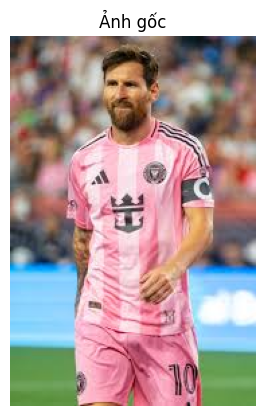

In [2]:
# Đọc ảnh
img = cv.imread('hinh1.jpg')

# Kiểm tra ảnh
if img is None:
    print(" Không đọc được ảnh")
else:
    print(" Đọc ảnh thành công")

# Chuyển BGR → RGB để hiển thị đúng màu
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Hiển thị ảnh
TenSV.imshow(img_rgb)
TenSV.title("Ảnh gốc")
TenSV.axis('off')

(np.float64(-0.5), np.float64(182.5), np.float64(274.5), np.float64(-0.5))

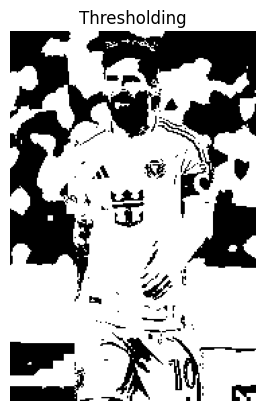

In [3]:
# Chuyển sang ảnh xám
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Áp dụng threshold
_, thresh = cv.threshold(gray, 127, 255, cv.THRESH_BINARY)

# Hiển thị
TenSV.imshow(thresh, cmap='gray')
TenSV.title("Thresholding")
TenSV.axis('off')

(np.float64(-0.5), np.float64(182.5), np.float64(274.5), np.float64(-0.5))

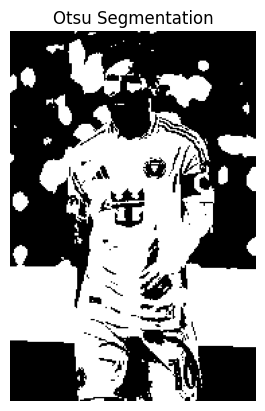

In [4]:
# Otsu threshold
_, otsu = cv.threshold(gray, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

# Hiển thị
TenSV.imshow(otsu, cmap='gray')
TenSV.title("Otsu Segmentation")
TenSV.axis('off')

(np.float64(-0.5), np.float64(182.5), np.float64(274.5), np.float64(-0.5))

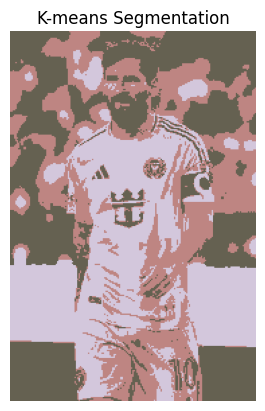

In [5]:
# Reshape ảnh thành vector
Z = img.reshape((-1,3))
Z = np.float32(Z)

# Số cụm K
K = 3

# Tiêu chí dừng
criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 10, 1.0)

# Áp dụng K-means
_, label, center = cv.kmeans(Z, K, None, criteria, 10, cv.KMEANS_RANDOM_CENTERS)

# Chuyển về uint8
center = np.uint8(center)
res = center[label.flatten()]
result = res.reshape((img.shape))

# Hiển thị
result_rgb = cv.cvtColor(result, cv.COLOR_BGR2RGB)

TenSV.imshow(result_rgb)
TenSV.title("K-means Segmentation")
TenSV.axis('off')

(np.float64(-0.5), np.float64(182.5), np.float64(274.5), np.float64(-0.5))

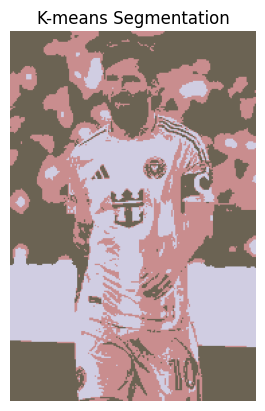

In [6]:
# Reshape ảnh thành vector
Z = img.reshape((-1,3))
Z = np.float32(Z)

# Số cụm K
K = 3

# Tiêu chí dừng
criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 10, 1.0)

# Áp dụng K-means
_, label, center = cv.kmeans(Z, K, None, criteria, 10, cv.KMEANS_RANDOM_CENTERS)

# Chuyển về uint8
center = np.uint8(center)
res = center[label.flatten()]
result = res.reshape((img.shape))

# Hiển thị
result_rgb = cv.cvtColor(result, cv.COLOR_BGR2RGB)

TenSV.imshow(result_rgb)
TenSV.title("K-means Segmentation")
TenSV.axis('off')

(np.float64(-0.5), np.float64(182.5), np.float64(274.5), np.float64(-0.5))

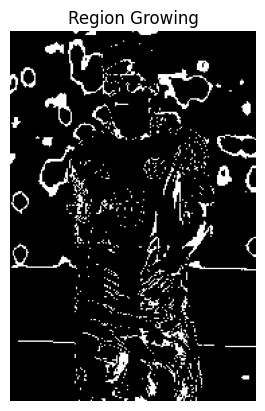

In [7]:
# Tạo ảnh output
segmented = np.zeros_like(gray)

# Chọn seed point (tọa độ)
seed_x, seed_y = 100, 100
threshold = 10

# Giá trị seed
seed_value = gray[seed_x, seed_y]

# Duyệt từng pixel
for i in range(gray.shape[0]):
    for j in range(gray.shape[1]):
        if abs(int(gray[i,j]) - int(seed_value)) < threshold:
            segmented[i,j] = 255

# Hiển thị
TenSV.imshow(segmented, cmap='gray')
TenSV.title("Region Growing")
TenSV.axis('off')

(np.float64(-0.5), np.float64(182.5), np.float64(274.5), np.float64(-0.5))

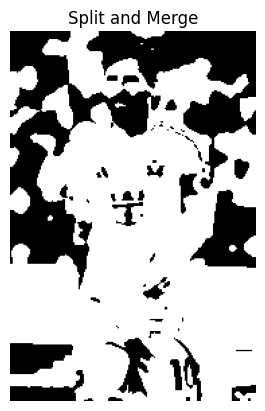

In [8]:
# Dùng GaussianBlur + threshold giả lập split & merge
blur = cv.GaussianBlur(gray, (5,5), 0)

_, split_merge = cv.threshold(blur, 127, 255, cv.THRESH_BINARY)

# Hiển thị
TenSV.imshow(split_merge, cmap='gray')
TenSV.title("Split and Merge")
TenSV.axis('off')

(np.float64(-0.5), np.float64(182.5), np.float64(274.5), np.float64(-0.5))

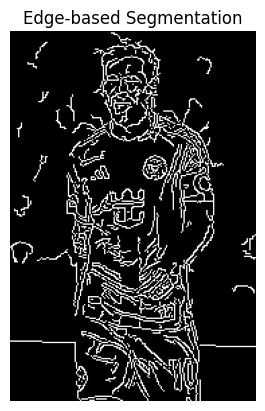

In [9]:
# Dùng Canny edge detection
edges = cv.Canny(gray, 100, 200)

# Hiển thị
TenSV.imshow(edges, cmap='gray')
TenSV.title("Edge-based Segmentation")
TenSV.axis('off')

# Lab 08